In [1]:
import numpy as np
import torch
from src.model.dnn import forwardMLP

from src.scripts.load_data import get_paths_for_forward_training
from train_forward import build_dataloaders
from train_forward import inference




/home/vpatro/anaconda3/envs/dnn_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_path = '/home/vpatro/DLPhotonicSurfaces/TNN/src/forwardDNN/airfoil_re_1_3_forward_DNN.pth'

model = forwardMLP(input_size=5, output_size=75)
model.load_state_dict(torch.load(model_path))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


dataset_name = 'airfoil_re_1_3'
train_input_path, train_output_path, test_input_path, test_output_path = get_paths_for_forward_training(dataset_name)
train_loader, val_loader, test_loader, input_size, output_size = build_dataloaders(train_input_path, train_output_path, test_input_path, test_output_path, device, dataset_name)

targets = np.load(test_output_path)
predictions, rmse_loss = inference(model, test_loader)



--------------------
LOADED airfoil_re_1_3 DATASET
--------------------

Using device: cuda
shape of input train data:  (2300, 5)
shape of output train data:  (2300, 75)
shape of input test data:  (1096, 5)
shape of output test data:  (1096, 75)
------------------
-----INFERENCE----
------------------


100%|██████████| 1096/1096 [00:00<00:00, 2519.23it/s]

Mean RMSE: 0.768333
Std RMSE: 0.18218155
Min RMSE: 0.27410927
Max RMSE: 1.7370188
------------------
INFERENCE COMPLETE
------------------


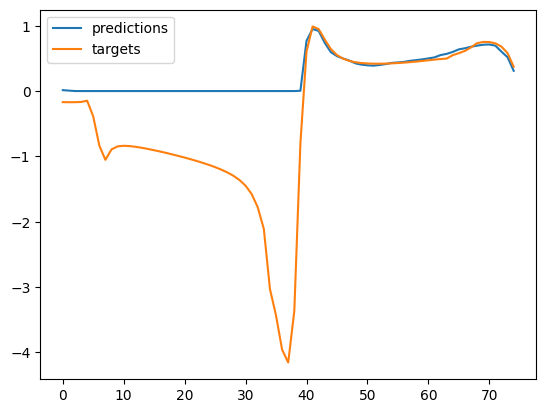

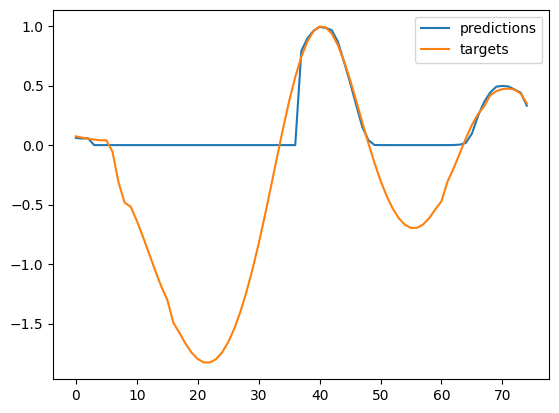

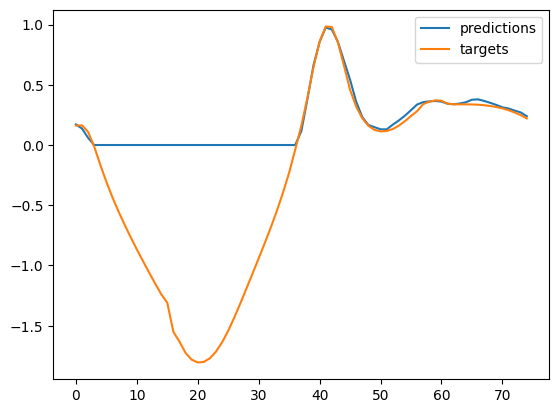

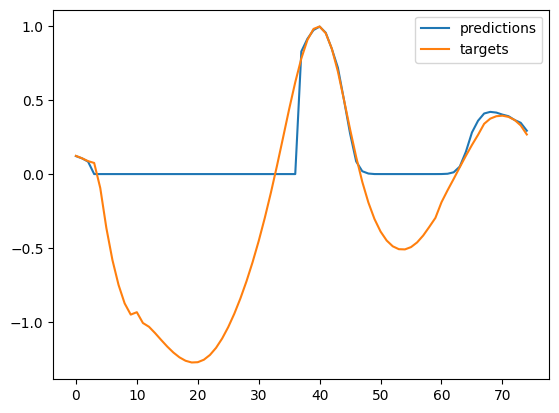

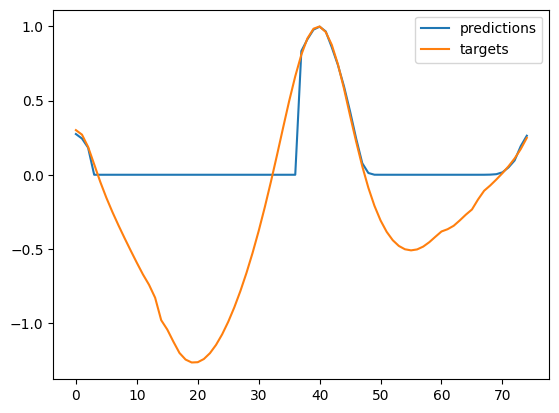

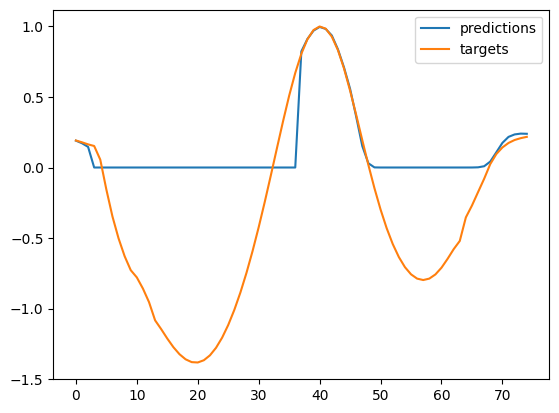

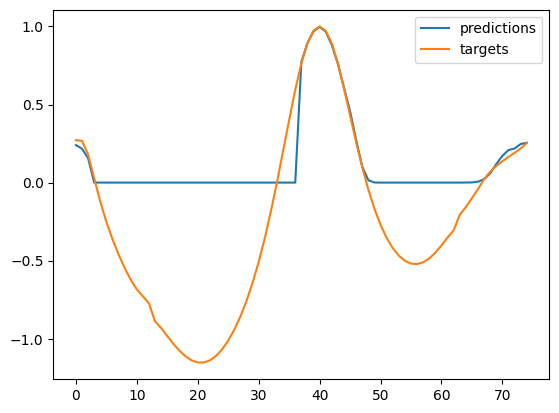

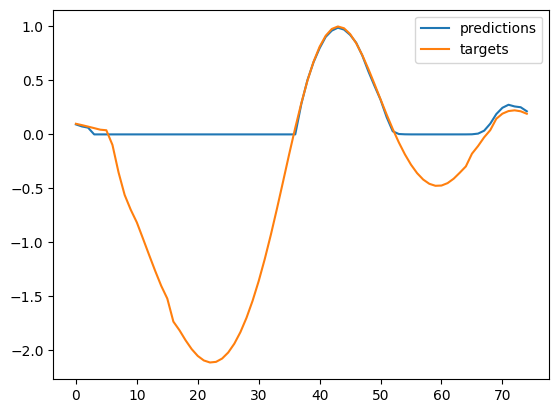

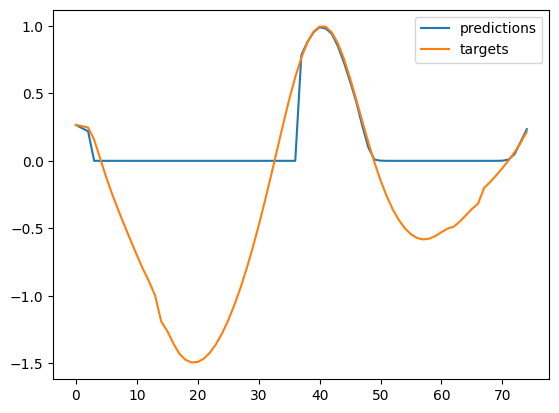

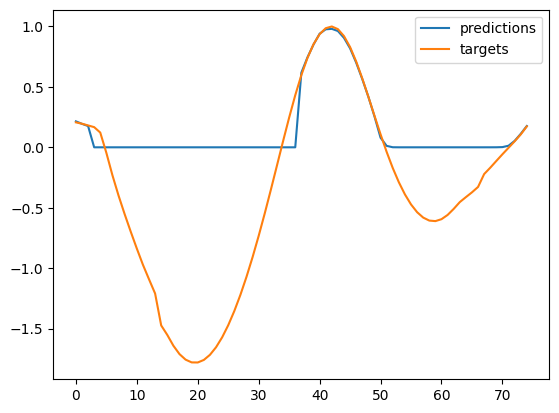

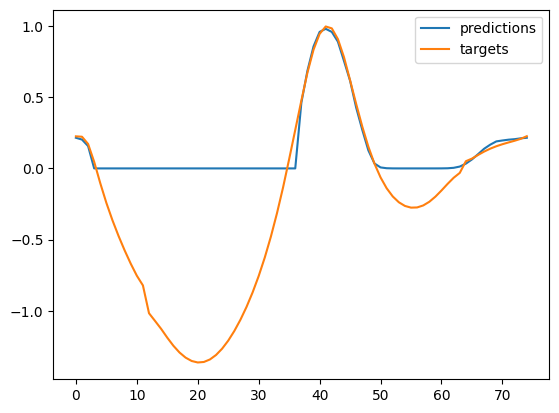

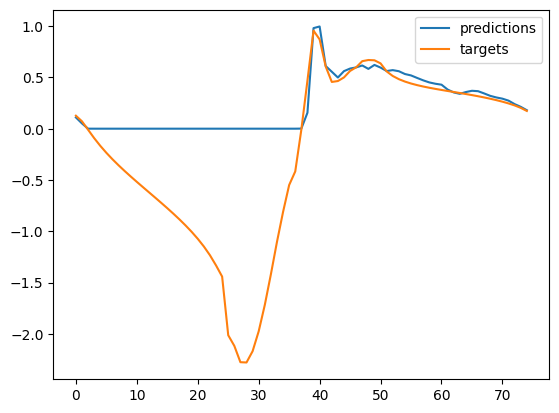

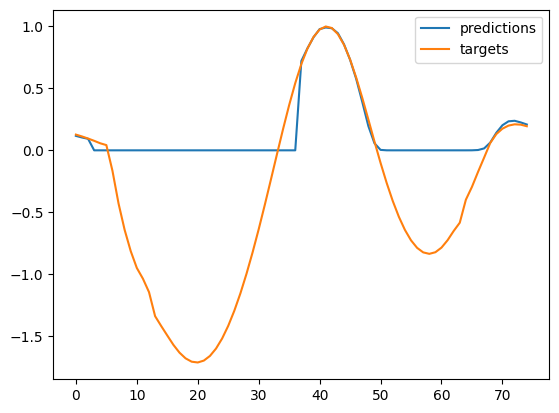

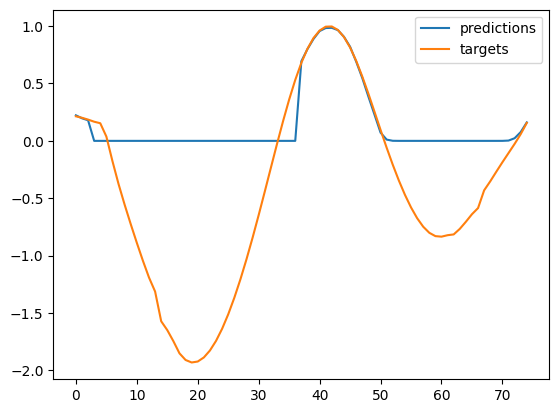

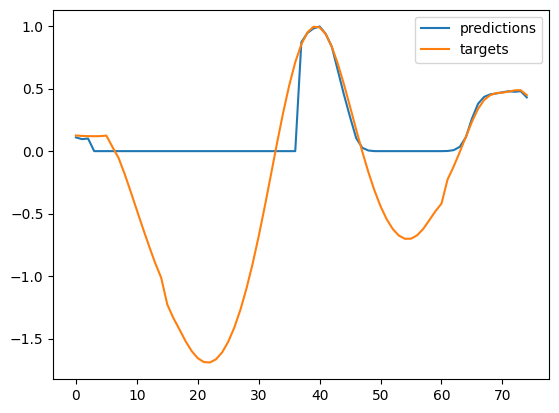

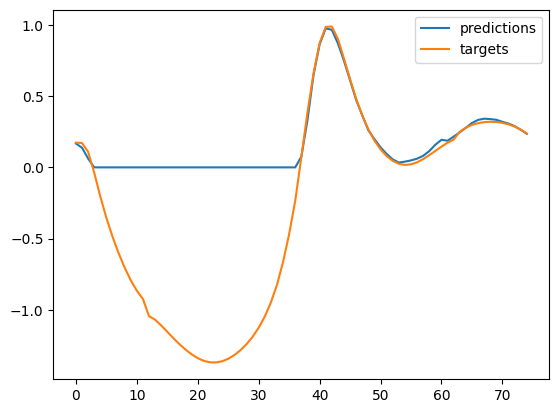

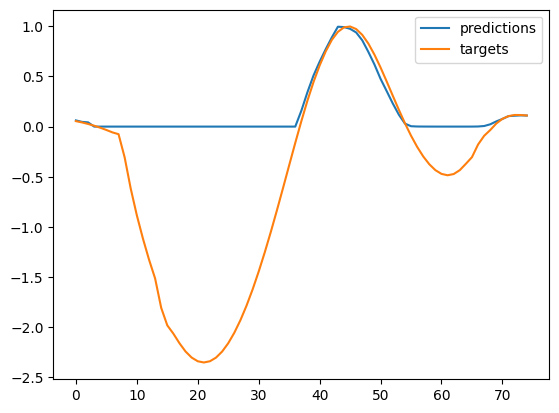

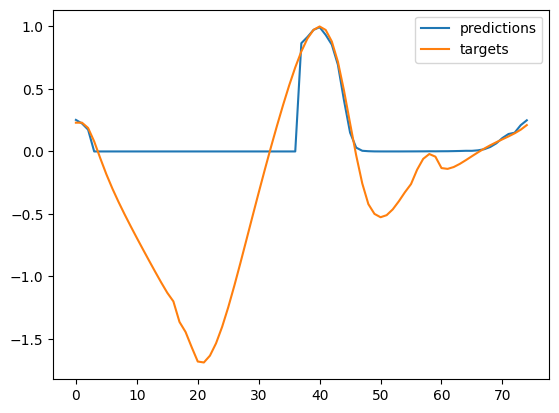

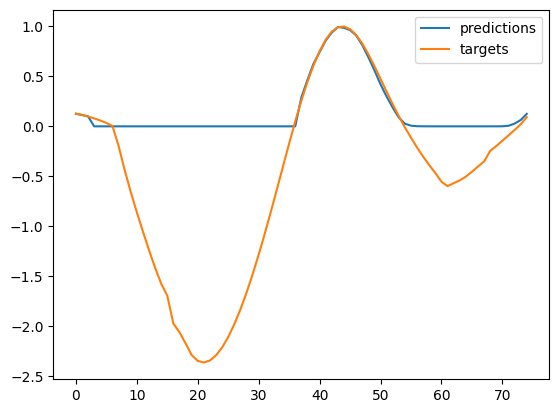

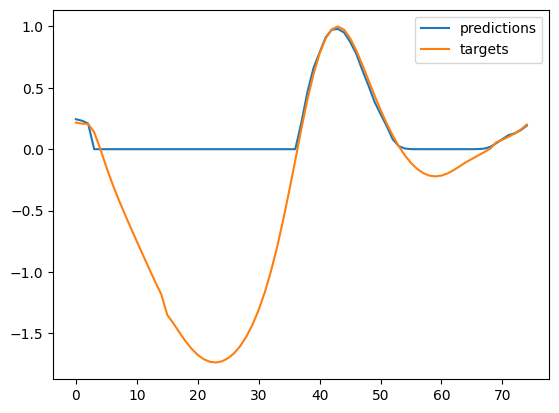

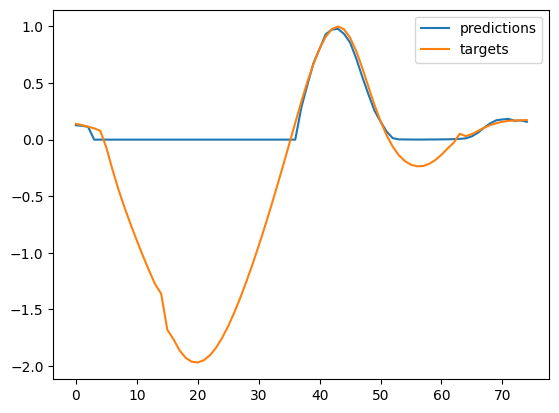

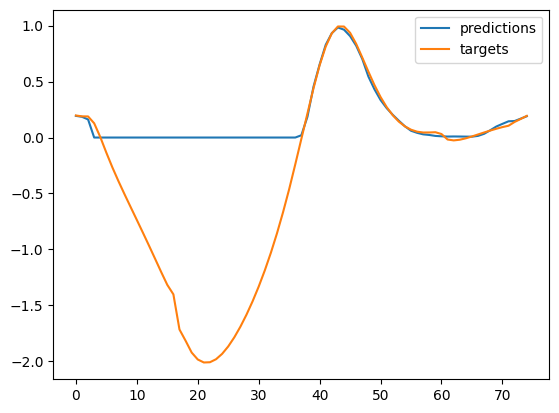

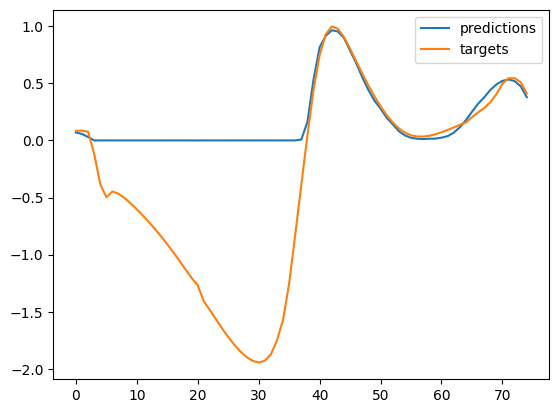

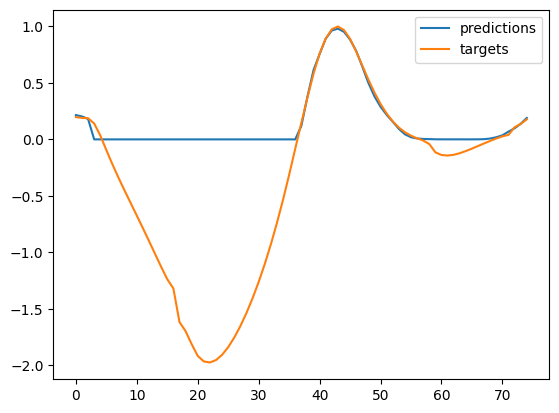

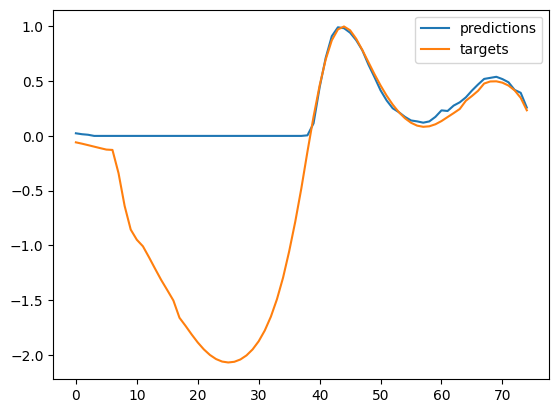

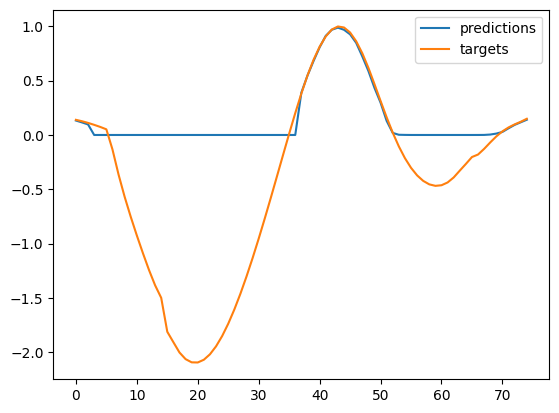

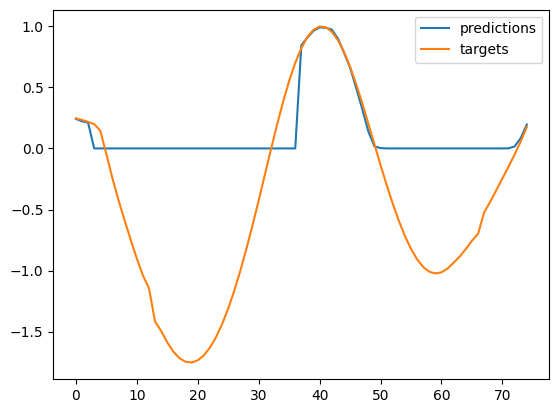

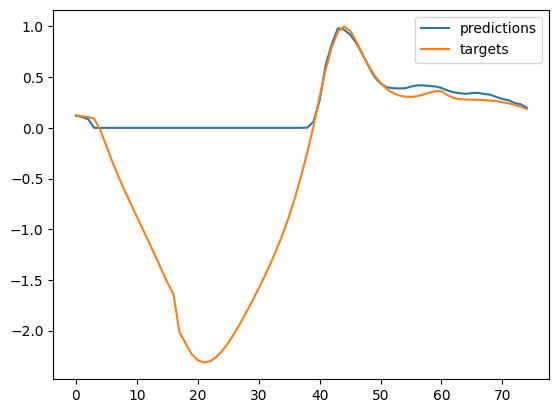

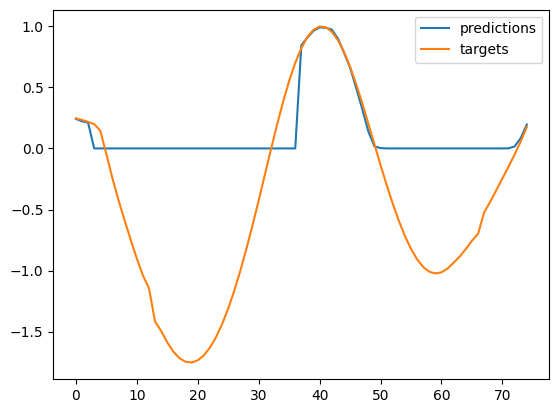

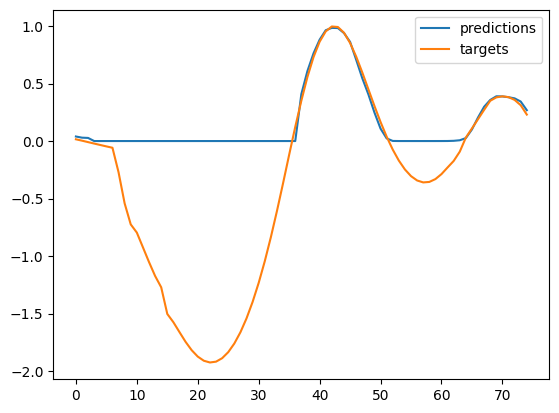

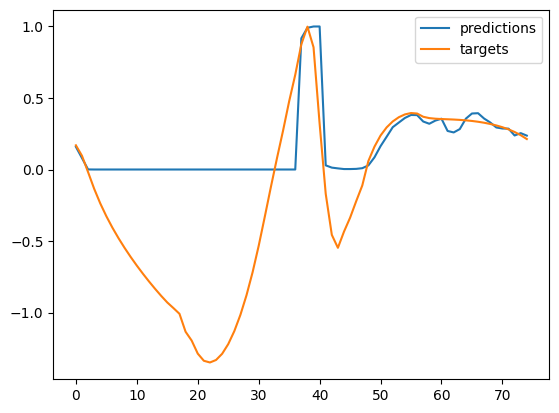

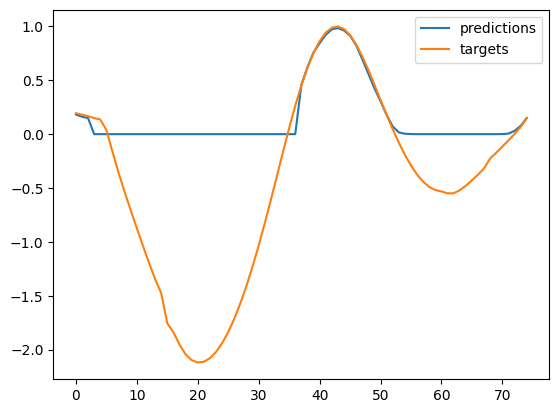

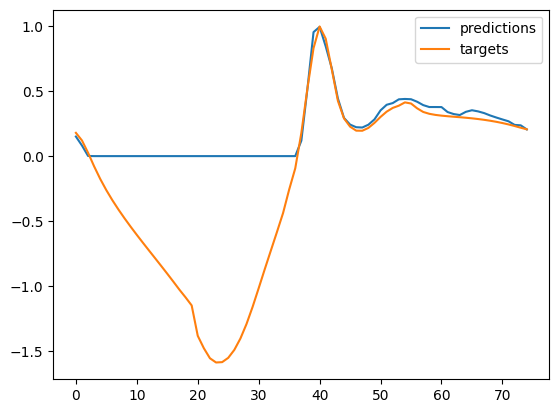

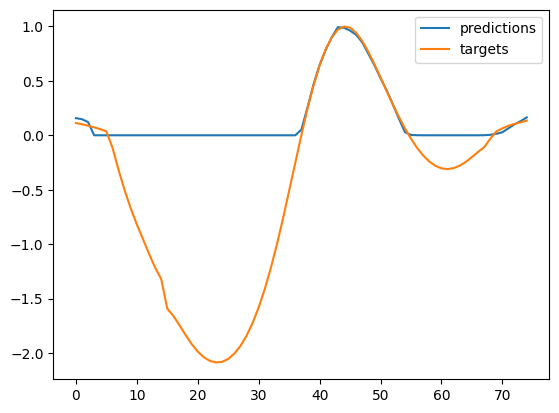

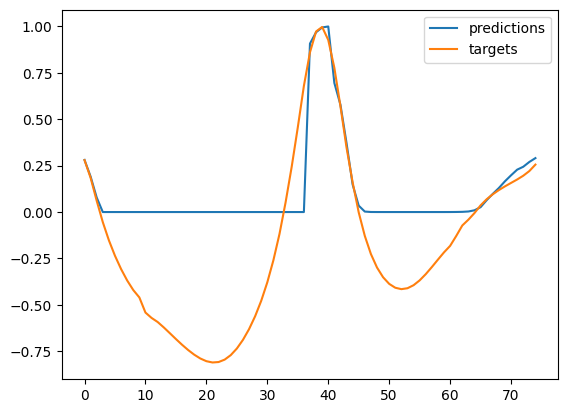

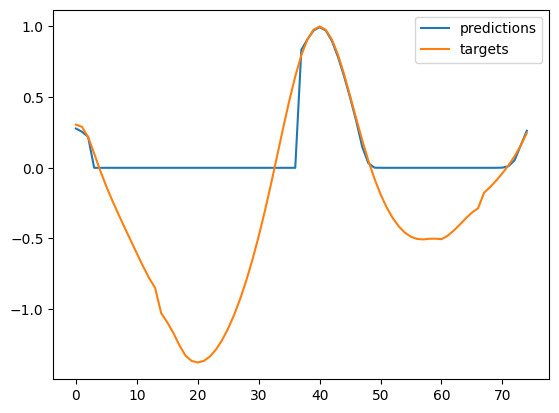

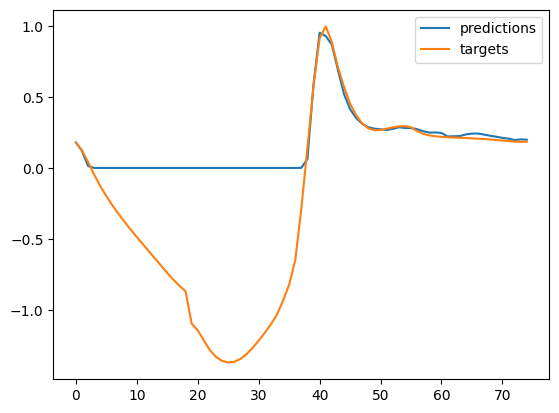

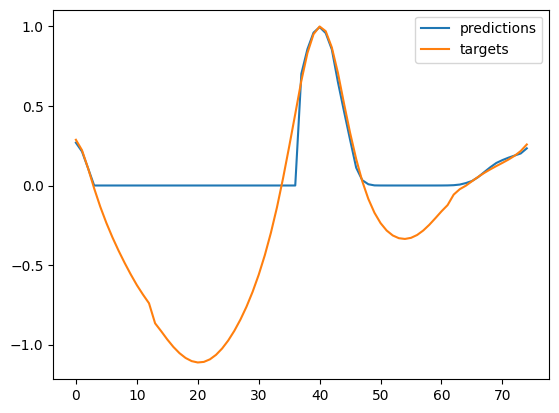

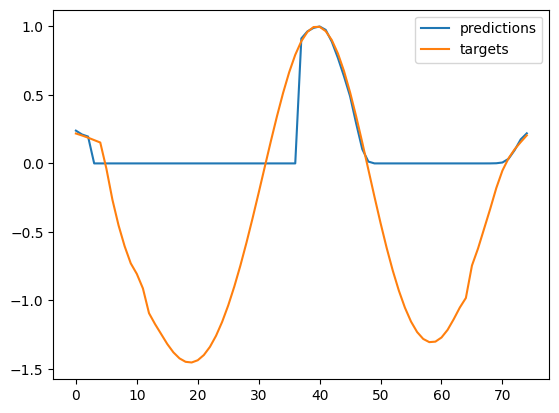

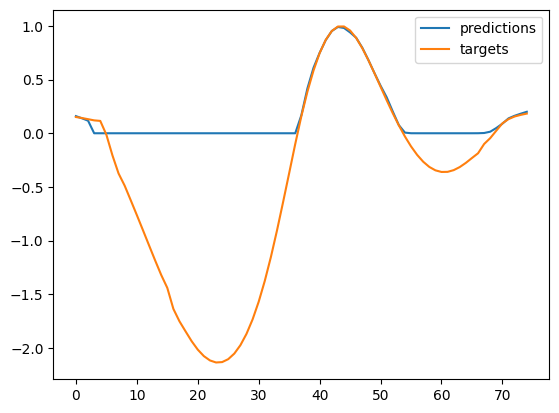

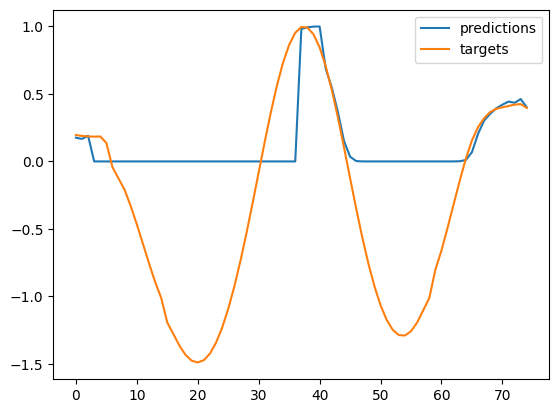

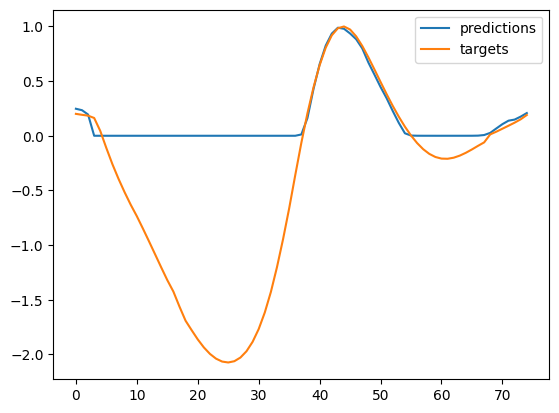

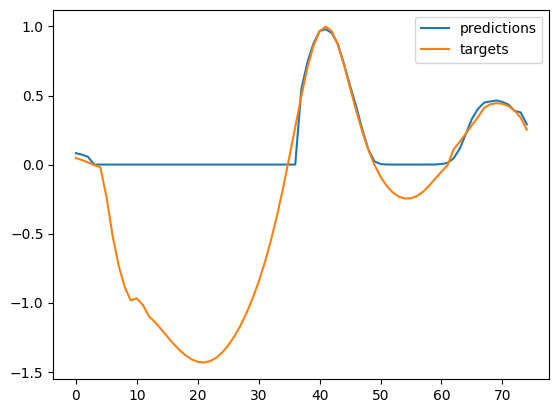

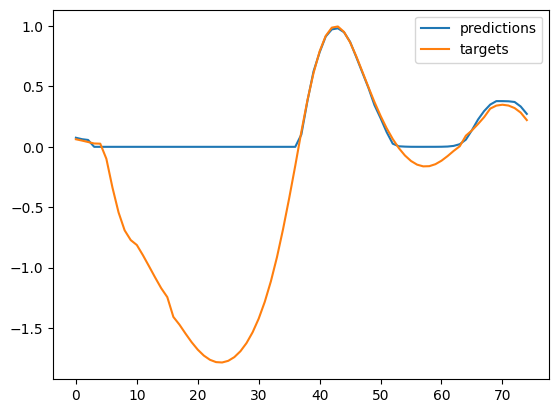

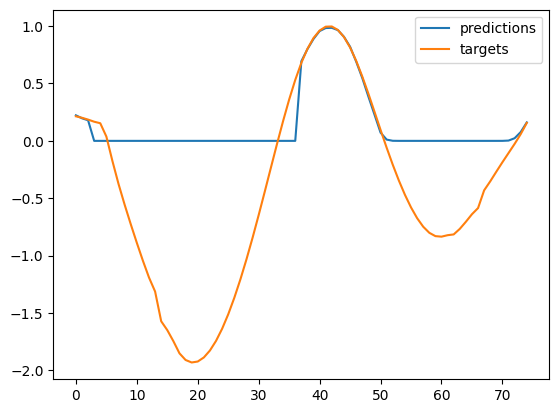

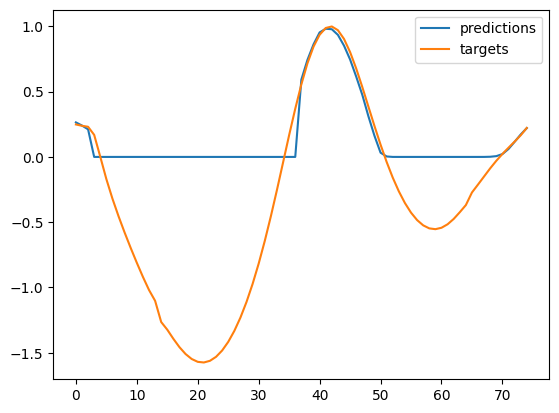

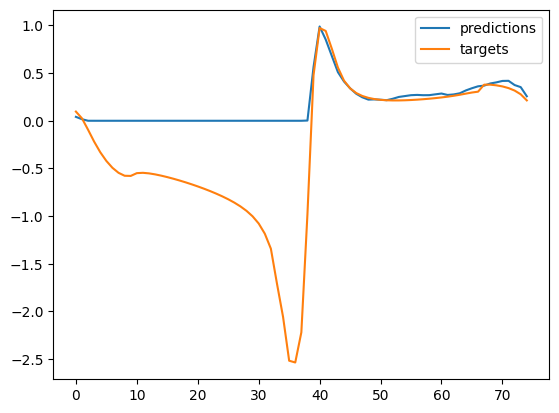

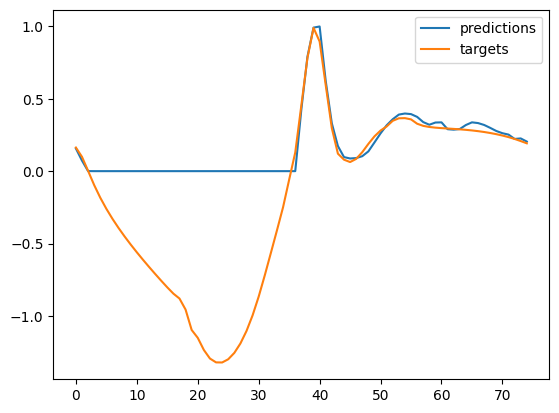

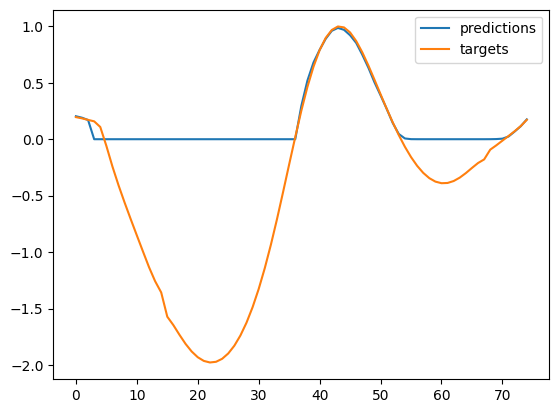

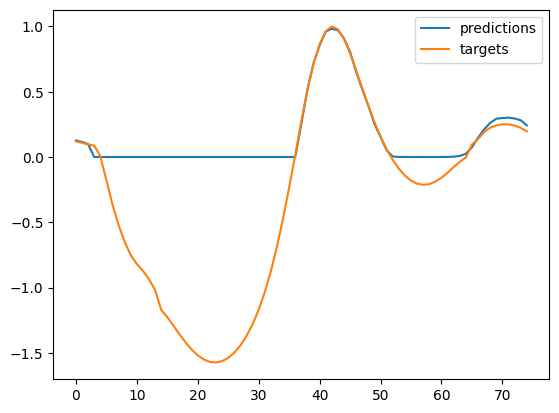

In [3]:
import matplotlib.pyplot as plt
np.random.seed(42)


n_trials = 50

for i in range(n_trials):
    sample_idx = np.random.randint(predictions.shape[0])
    plt.plot(predictions[sample_idx, :], label='predictions')
    plt.plot(targets[sample_idx, :], label='targets')
    plt.legend()
    plt.show()

In [5]:
import joblib

dataset_name = 'airfoil_re_1_3'
model_path = f'src/forwardDNN/{dataset_name}_forward_XGBR.pkl'

from train_forward_airfoil import load_data
import train_forward_airfoil

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_input_path, train_output_path, test_input_path, test_output_path = get_paths_for_forward_training(dataset_name)
X_train, y_train, X_test, y_test = load_data(train_input_path, train_output_path, test_input_path, test_output_path, device, dataset_name)

model_path = f'src/forwardDNN/{dataset_name}_forward_XGBR.pkl'
model = joblib.load(model_path)

result = train_forward_airfoil.inference(model, X_test, y_test)
type(result)



--------------------
LOADED airfoil_re_1_3 DATASET
--------------------

Using device: cuda
shape of input train data:  (2300, 5)
shape of output train data:  (2300, 75)
shape of input test data:  (1096, 5)
shape of output test data:  (1096, 75)
------------
INFERENCE BEGINNING
LOADING PRETRAINED MODEL
------------
INFERENCE COMPLETE
------------
y pred is of type:  <class 'numpy.ndarray'>
test_rmse is of type:  <class 'numpy.float64'>


tuple

In [6]:
y_pred, test_rmse = result

In [ ]:
np.random.seed(42)


n_trials = 50

for i in range(n_trials):
    sample_idx = np.random.randint(y_pred.shape[0])
    plt.plot(y_pred[sample_idx, :], label='predictions')
    plt.plot(y_test[sample_idx, :], label='targets')
    plt.legend()
    plt.show()